## 0 · Setup ▶️  *(run this one cell)*

Makes a synthetic night-time road frame so the notebook is self-contained. Don't read it — press play.
*(In the real project you'd `cv2.imread("frame.jpg")` from an actual traffic camera instead.)*

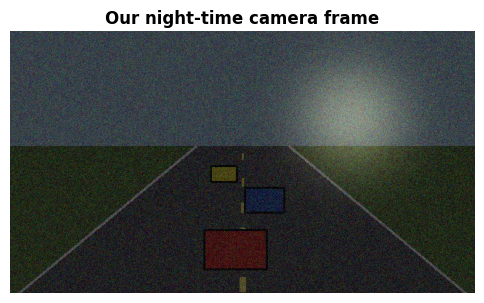

frame shape: (360, 640, 3)


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def _make_night_frame(seed=3):
    g=np.random.default_rng(seed); H,W=360,640
    img=np.zeros((H,W,3),np.uint8); img[:158]=(165,193,214); img[158:]=(96,120,72)
    road=np.array([[int(W*0.40),158],[int(W*0.60),158],[int(W*0.98),H],[int(W*0.02),H]],np.int32)
    cv2.fillPoly(img,[road],(92,92,98))
    for y in range(168,H,34):
        t=(y-158)/(H-158); w=int(2+8*t)
        cv2.rectangle(img,(W//2-w//2,y),(W//2+w//2,y+int(8+14*t)),(235,225,120),-1)
    cv2.line(img,(int(W*0.40),158),(int(W*0.02),H),(230,230,235),2)
    cv2.line(img,(int(W*0.60),158),(int(W*0.98),H),(230,230,235),2)
    def car(cx,cy,w,h,c):
        cv2.rectangle(img,(cx-w//2,cy-h//2),(cx+w//2,cy+h//2),c,-1)
        cv2.rectangle(img,(cx-w//2,cy-h//2),(cx+w//2,cy+h//2),(20,20,20),2)
    car(W//2-10,300,86,54,(190,60,55)); car(W//2+30,232,54,34,(60,90,170)); car(W//2-26,196,36,22,(210,200,60))
    night=img.astype(np.float32)*0.34 + g.normal(0,16,img.shape)
    glare=np.zeros((H,W),np.float32); cv2.circle(glare,(470,120),60,1.0,-1); glare=cv2.GaussianBlur(glare,(0,0),40)
    night+=glare[...,None]*np.array([120,120,90])
    return np.clip(night,0,255).astype(np.uint8)   # RGB

frame = _make_night_frame()

# a small helper so we can show images nicely (and grayscale ones in gray)
def show(img, title="", gray=False):
    plt.figure(figsize=(6,3.4))
    plt.imshow(img, cmap="gray" if gray else None, vmin=0 if gray else None, vmax=255 if gray else None)
    plt.title(title, fontweight="bold"); plt.axis("off"); plt.show()

show(frame, "Our night-time camera frame")
print("frame shape:", frame.shape)

## 1 · Warm-up — an image is just an array ▶️

Recall from the lecture: the image is a grid of numbers. Let's prove it — check its shape, peek at one pixel, crop it, and turn it grayscale.

shape (height, width, colours): (360, 640, 3)
one pixel [R, G, B]: [78 28 54]


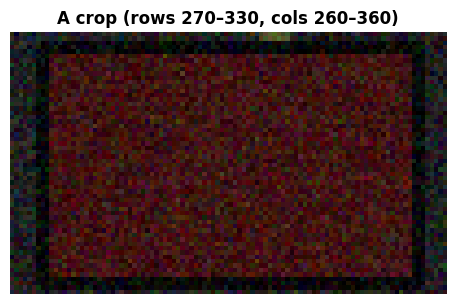

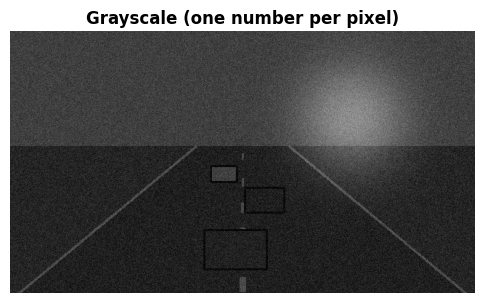

In [ ]:
print("shape (height, width, colours):", frame.shape)
print("one pixel [R, G, B]:", frame[300, 320])      # row 300, column 320

# crop = slice rows, then columns (just like a list of lists)
crop = frame[270:330, 260:360]                       # around the nearest car
show(crop, "A crop (rows 270–330, cols 260–360)")

# grayscale = collapse 3 colour layers into 1 brightness layer
gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
show(gray, "Grayscale (one number per pixel)", gray=True)

**✏️ Your turn 1** — change the crop to grab a *different* car (try the small far car near the top, around rows 180–215, cols 290–330). Run it.

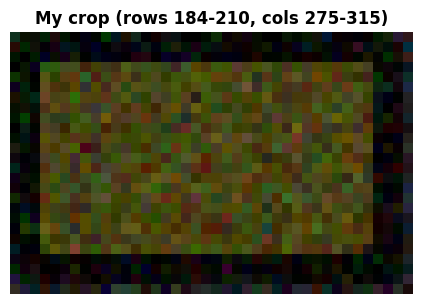

In [ ]:
# ✏️ Your turn 1 — change these four numbers to crop a different car
crop2 = frame[184:210, 275:315]       # <- edit rows/cols
show(crop2, "My crop (rows 184-210, cols 275-315)")

## 2 · Three preprocessing pipelines

A **pipeline** is just a few steps applied in order. We'll build three different recipes, then see which one makes the cars easiest to see. We always start from the grayscale frame.

**▶ Build together — Pipeline A: brighten only (CLAHE)**

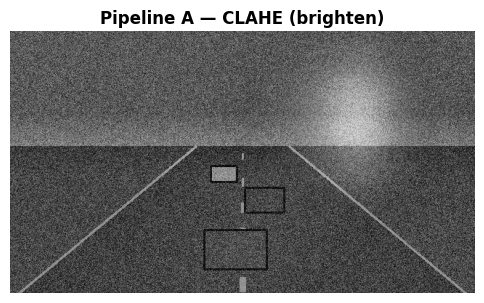

In [ ]:
# CLAHE = adaptive brightening — lifts detail out of dark areas.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
pipeline_A = clahe.apply(gray)
show(pipeline_A, "Pipeline A — CLAHE (brighten)", gray=True)

**▶ Build together — Pipeline B: blur, then brighten**

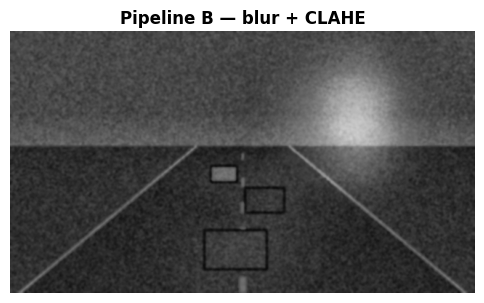

In [ ]:
# Blur first to calm the noise, THEN brighten.
blur = cv2.GaussianBlur(gray, (7,7), 0)
pipeline_B = clahe.apply(blur)
show(pipeline_B, "Pipeline B — blur + CLAHE", gray=True)

**▶ Build together — Pipeline C: blur, brighten, then edges**

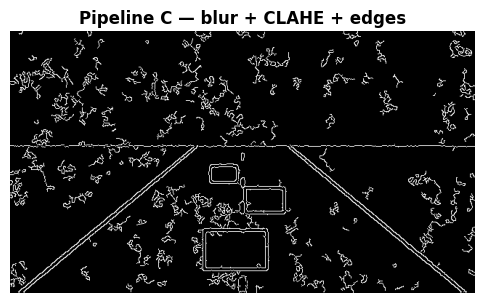

In [ ]:
# Same as B, then trace outlines with Canny edge detection.
pipeline_C = cv2.Canny(pipeline_B, 30, 90)
show(pipeline_C, "Pipeline C — blur + CLAHE + edges", gray=True)

**✏️ Your turn 2 — make your own Pipeline D.** Mix the steps however you like — change the blur size, the CLAHE `clipLimit`, or the Canny numbers. Try to make the cars as clear as you can.

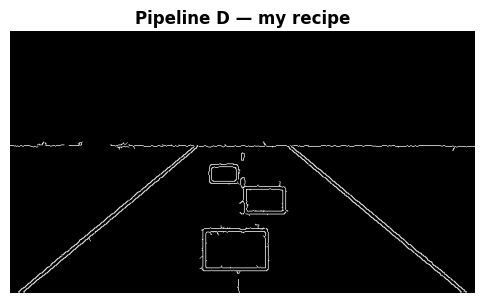

In [ ]:
# ✏️ Your turn 2 — experiment! (this is a starting point — change the numbers)
step1 = cv2.GaussianBlur(gray, (7,7), 0)
step2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(step1)
pipeline_D = cv2.Canny(step2, 50, 130)
show(pipeline_D, "Pipeline D — my recipe", gray=True)

## 3 · Compare them — side by side ▶️

Eyeballing is a start, but research needs a *number*. We'll use **edge count**: how many edge pixels Canny finds. More clean edges (around real shapes, not noise) usually means the cars are easier to pick out.

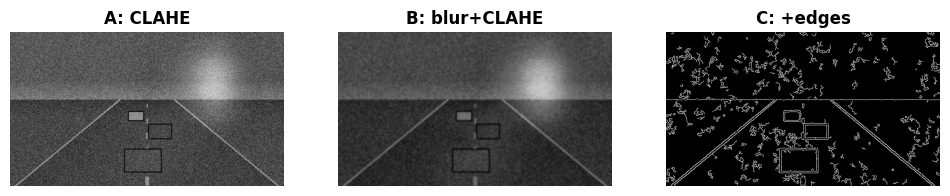

In [ ]:
# Show the three side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, img, name in zip(axes, [pipeline_A, pipeline_B, pipeline_C],
                         ["A: CLAHE", "B: blur+CLAHE", "C: +edges"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255); ax.set_title(name, fontweight="bold"); ax.axis("off")
plt.show()

In [ ]:
# A simple score: count edge pixels each pipeline produces (after Canny)
def edge_count(img):
    # if it's already edges (0/255), count directly; otherwise run Canny first
    e = img if set(np.unique(img)).issubset({0,255}) else cv2.Canny(img, 30, 90)
    return int((e > 0).sum())

for name, img in [("Raw grayscale", gray), ("A: CLAHE", pipeline_A),
                  ("B: blur+CLAHE", pipeline_B), ("C: edges", pipeline_C),
                  ("D: yours", pipeline_D)]:
    print(f"{name:<16} edge pixels: {edge_count(img):>6}")

Raw grayscale    edge pixels:  78131
A: CLAHE         edge pixels:  84984
B: blur+CLAHE    edge pixels:  13750
C: edges         edge pixels:  13750
D: yours         edge pixels:   3737


**Read the numbers, not just the pictures.** Raw grayscale often has a *huge* edge count — but most are **noise**, not cars. Blurring first usually drops the count toward the real shapes. The 'best' pipeline isn't simply the highest or lowest number; it's the one where the edges sit on the **cars and lane lines**, not scattered everywhere. Look back at the pictures to judge.

## 4 · Your findings ✍️

In **two or three sentences**:

1. **Which pipeline** made the cars easiest to see, and what's its edge count?
2. **Why** do you think it won? (e.g. "blurring first removed the noise so the edges landed on the cars.")
3. **One idea** you'd try next to do even better.

> This is the start of Wrong-Way **Sub-Problem A**: choosing the right preprocessing for each frame. You just did it by hand — the research goal is to make it automatic.

In [ ]:
findings = """
1. Best pipeline: Pipeline D (3737 Edge Pixels)
2. Why it won: It was able to filter out most of the noise due to a higher Canny threshold value.
3. What I'd try next: Fine a way to reduce the noise directly surrounding the boxes and making them more smooth.
"""
print(findings)


1. Best pipeline: Pipeline D (3737 Edge Pixels)
2. Why it won: It was able to filter out most of the noise due to a higher Canny threshold value.
3. What I'd try next: Fine a way to reduce the noise directly surrounding the boxes and making them more smooth.



## 5 · Save your work ✔️

Saved wed_pipelines.png — your deliverable (3 pipelines on a sample frame).


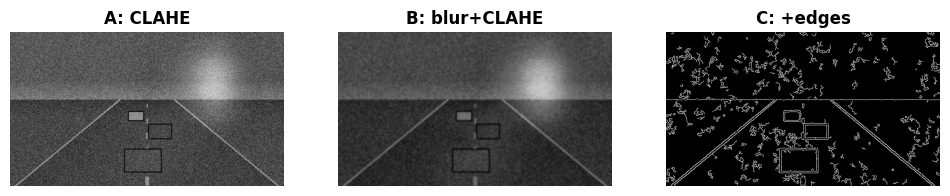

In [ ]:
# Save your three pipelines side by side as the lab deliverable.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, img, name in zip(axes, [pipeline_A, pipeline_B, pipeline_C],
                         ["A: CLAHE", "B: blur+CLAHE", "C: +edges"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255); ax.set_title(name, fontweight="bold"); ax.axis("off")
fig.savefig("wed_pipelines.png", dpi=150, bbox_inches="tight")
print("Saved wed_pipelines.png — your deliverable (3 pipelines on a sample frame).")

---
## Homework — due before Thursday (~30 min)

1. **Build one more pipeline** that handles the **glare** (the bright blob). Hint: try thresholding, or look at the HSV version of the frame (`cv2.cvtColor(frame, cv2.COLOR_RGB2HSV)`).
2. **Write 2–3 sentences**: which of your pipelines you'd trust on a night frame, and why — back it up with the edge-count number.
3. **Bring it** Thursday.

---
## Completed Homework:

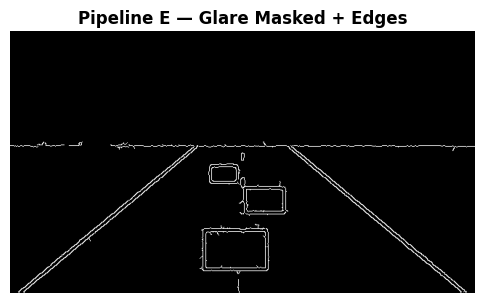

Edge Count:  3737


In [ ]:
hsv = cv2.cvtColor(frame, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv)

_, glare_mask = cv2.threshold(v, 240, 255, cv2.THRESH_BINARY)
glare_mask_inv = cv2.bitwise_not(glare_mask)
gray_no_glare = cv2.bitwise_and(gray, gray, mask=glare_mask_inv)

step1 = cv2.GaussianBlur(gray_no_glare, (7, 7), 0)
step2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(step1)
pipeline_E = cv2.Canny(step2, 50, 130)

show(pipeline_E, "Pipeline E — Glare Masked + Edges", gray=True)
print("Edge Count: ", edge_count(pipeline_E))

In [ ]:
explanation = """
The pipeline I would trust I'd trust on a nightframe is Pipeline E, and this is because it \ncreated more precise boxes around the cars and lane-markings compared to the other pipelines. \nThis is evident by its edge count, which is 3737 pixels.
"""
print(explanation)


The pipeline I would trust I'd trust on a nightframe is Pipeline E, and this is because it 
created more precise boxes around the cars and lane-markings compared to the other pipelines. 
This is evident by its edge count, which is 3737 pixels.



---
## 6 · Bonus — run a *real* detector 🚗  *(Colab only)*

This is the modern, **learned** detector from the lecture (YOLO). You don't train it — you download one already trained on millions of images (it knows ~80 everyday objects: person, car, bus, …) and point it at a picture.


In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 6.0 MB/s eta 0:00:00


**▶ Build together — load the model and run it on a sample street image**

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 235.1ms
Speed: 6.4ms preprocess, 235.1ms inference, 28.7ms postprocess per image at shape (1, 3, 640, 480)


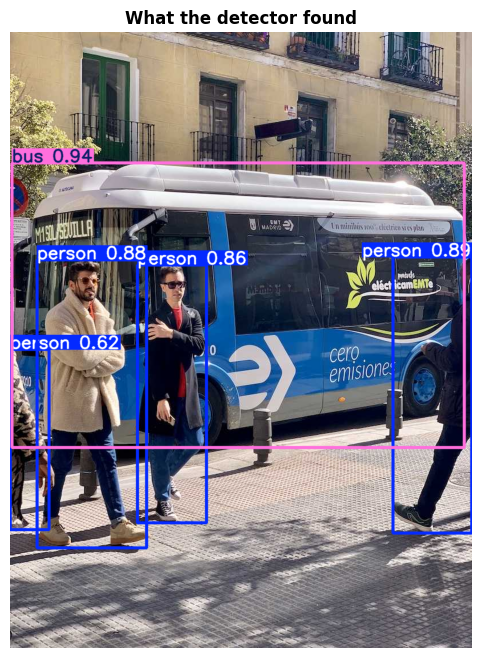

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt   # cv2 is already imported from the setup cell

model = YOLO("yolo11n.pt")                                   # 'n' = nano, the small fast one
results = model("https://ultralytics.com/images/bus.jpg")    # a sample street photo

annotated = results[0].plot()                                # draw the boxes (returns a BGR image)
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))        # BGR -> RGB so colours are right
plt.axis("off"); plt.title("What the detector found", fontweight="bold"); plt.show()

**▶ Build together — read the detections** (each box = class + confidence + location)

In [ ]:
r = results[0]
print(f"Found {len(r.boxes)} objects:\n")
for box in r.boxes:
    name = r.names[int(box.cls)]          # e.g. "person", "bus", "car"
    conf = float(box.conf)                # how sure, 0-1
    x1, y1, x2, y2 = [round(v) for v in box.xyxy[0].tolist()]   # box corners
    print(f"  {name:<8} {conf:.2f}   box=({x1},{y1})-({x2},{y2})")

Found 5 objects:

  bus      0.94   box=(4,229)-(796,728)
  person   0.89   box=(671,395)-(810,879)
  person   0.88   box=(47,400)-(239,904)
  person   0.86   box=(223,409)-(344,860)
  person   0.62   box=(0,556)-(69,872)


**✏️ Your turn** — point it at a *different* image. Paste any image URL, or upload a file in Colab (folder icon on the left) and use its filename. The `conf=` setting is the **confidence threshold** from the lecture — only keep detections the model is at least that sure about.


image 1/1 /content/HF7oEKHasAQlFOS.jpg: 640x512 1 car, 1 potted plant, 149.8ms
Speed: 2.8ms preprocess, 149.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 512)


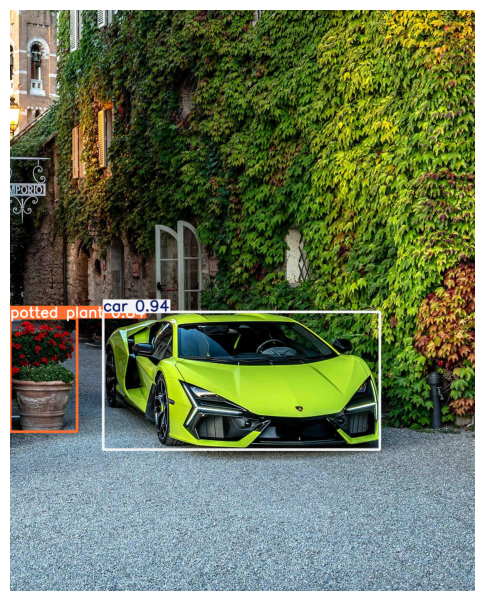

In [ ]:
# ✏️ Your turn — change the image, and try raising/lowering conf (0.25 - 0.7)
my_image = "https://pbs.twimg.com/media/HF7oEKHasAQlFOS.jpg"     # <- swap in your own URL or filename
res = model(my_image, conf=0.5)

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

**How this ties together:** the detector only works well if it can actually *see* the objects — so on a dark traffic frame you'd run your **preprocessing pipeline first** (Part 2), *then* the detector. Cleaning the picture and detecting are two halves of the same job.